<a href="https://colab.research.google.com/github/gopalstud86/GenAI-Assignments/blob/main/Bronze%20Badge%20Assignments/Problem2_Predict_loan_default_with_KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [46]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix


In [47]:
#Load Data

dataFile = "https://raw.githubusercontent.com/gopalstud86/GenAI-Assignments/refs/heads/main/Bronze%20Badge%20Assignments/Datasets/CustomerLoanData.csv"
#dataFile= ("/CustomerLoanData.csv")
data = pd.read_csv(dataFile)
df = pd.DataFrame(data)
df.head()


,Age,AnnualIncome(lakhs),CreditScore(300-900),LoanAmount(lakhs),LoanTerm(years),EmploymentType,loan(Y/N)
0,28,6.5,720,5,5,Salaried,0
1,45,12.0,680,10,10,Self-Employed,1
2,35,8.0,750,6,7,Salaried,0
3,50,15.0,640,12,15,Self-Employed,1
4,30,7.0,710,5,5,Salaried,0


In [48]:
# Preprocessing

df.columns = df.columns.str.strip()
df = pd.get_dummies(df, columns=['EmploymentType'], drop_first=True)
df

,Age,AnnualIncome(lakhs),CreditScore(300-900),LoanAmount(lakhs),LoanTerm(years),loan(Y/N),EmploymentType_Self-Employed
0,28,6.5,720,5,5,0,False
1,45,12.0,680,10,10,1,True
2,35,8.0,750,6,7,0,False
3,50,15.0,640,12,15,1,True
4,30,7.0,710,5,5,0,False
5,42,10.0,660,9,10,1,False
6,26,5.5,730,4,4,0,False
7,48,14.0,650,11,12,1,True
8,38,9.0,700,7,8,0,False
9,55,16.0,620,13,15,1,True


In [49]:
#encode catgorical columns
df['EmploymentType_Self-Employed'] = df['EmploymentType_Self-Employed'].astype(int)
df

,Age,AnnualIncome(lakhs),CreditScore(300-900),LoanAmount(lakhs),LoanTerm(years),loan(Y/N),EmploymentType_Self-Employed
0,28,6.5,720,5,5,0,0
1,45,12.0,680,10,10,1,1
2,35,8.0,750,6,7,0,0
3,50,15.0,640,12,15,1,1
4,30,7.0,710,5,5,0,0
5,42,10.0,660,9,10,1,0
6,26,5.5,730,4,4,0,0
7,48,14.0,650,11,12,1,1
8,38,9.0,700,7,8,0,0
9,55,16.0,620,13,15,1,1


In [50]:
X = df.drop('loan(Y/N)', axis=1)
y = df['loan(Y/N)']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, stratify=y, random_state=42)

# KNN Model
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

Accuracy: 1.00
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00         7

    accuracy                           1.00        15
   macro avg       1.00      1.00      1.00        15
weighted avg       1.00      1.00      1.00        15

#Confusion Matrix:
[[8 0]
 [0 7]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00         7

    accuracy                           1.00        15
   macro avg       1.00      1.00      1.00        15
weighted avg       1.00      1.00      1.00        15



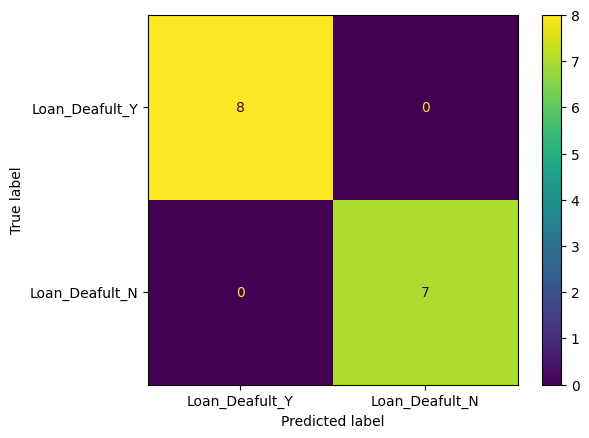

In [51]:
# Evaluation

accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print("Classification Report:")
print(report)

con_matrix = confusion_matrix(y_test, y_pred)
print("#Confusion Matrix:")
print(con_matrix)

cm_display = ConfusionMatrixDisplay(con_matrix, display_labels = ["Loan_Deafult_Y", "Loan_Deafult_N"])
cm_display.plot()
print(classification_report(y_test, y_pred))